# PyTorch 기반 클러스터링 실습: UCI Iris 데이터셋 + K-Means

Google Colab에서 바로 실행할 수 있는 `.ipynb` 노트북입니다.

- 데이터셋: UCI Machine Learning Repository의 Iris 데이터셋
- 알고리즘: PyTorch로 직접 구현한 K-Means 클러스터링
- 평가: Silhouette Score, ARI, NMI
- 시각화: PyTorch SVD 기반 PCA 2차원 시각화


## 1. 라이브러리 불러오기

In [1]:
# 표 형태의 데이터를 읽고 처리하기 위해 pandas를 불러옵니다.
import pandas as pd

# 배열 계산과 난수 처리를 위해 numpy를 불러옵니다.
import numpy as np

# 텐서 계산과 K-Means 직접 구현을 위해 PyTorch를 불러옵니다.
import torch

# 그래프 시각화를 위해 matplotlib의 pyplot을 불러옵니다.
import matplotlib.pyplot as plt

# 클러스터 내부 응집도와 군집 간 분리도를 평가하기 위해 silhouette_score를 불러옵니다.
from sklearn.metrics import silhouette_score

# 실제 라벨과 클러스터 결과의 일치 정도를 평가하기 위해 adjusted_rand_score를 불러옵니다.
from sklearn.metrics import adjusted_rand_score

# 실제 라벨과 클러스터 결과가 공유하는 정보량을 평가하기 위해 normalized_mutual_info_score를 불러옵니다.
from sklearn.metrics import normalized_mutual_info_score

# GPU가 사용 가능하면 GPU를 사용하고, 아니면 CPU를 사용하도록 연산 장치를 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PyTorch 난수 결과를 고정하여 같은 코드를 다시 실행해도 비슷한 결과가 나오도록 합니다.
torch.manual_seed(42)

# NumPy 난수 결과도 고정하여 실험 재현성을 높입니다.
np.random.seed(42)

# 현재 선택된 연산 장치를 출력합니다.
print("사용 장치:", device)

사용 장치: cuda


## 2. UCI Iris 데이터셋 다운로드

In [2]:
# UCI Machine Learning Repository에 공개된 Iris 데이터셋 원본 CSV 주소를 지정합니다.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# 원본 CSV 파일에는 컬럼명이 없으므로 사용할 컬럼명을 직접 리스트로 작성합니다.
columns = [
    "sepal_length",  # 꽃받침 길이(cm)를 의미하는 수치형 특성입니다.
    "sepal_width",   # 꽃받침 너비(cm)를 의미하는 수치형 특성입니다.
    "petal_length",  # 꽃잎 길이(cm)를 의미하는 수치형 특성입니다.
    "petal_width",   # 꽃잎 너비(cm)를 의미하는 수치형 특성입니다.
    "species"        # 붓꽃 품종 이름을 의미하는 문자열 라벨입니다.
]

# 인터넷 URL에서 CSV 데이터를 읽어 pandas DataFrame으로 저장합니다.
df = pd.read_csv(url, names=columns)

# 혹시 빈 줄이나 결측 행이 포함된 경우를 대비하여 결측값이 있는 행을 제거합니다.
df = df.dropna()

# 데이터가 정상적으로 읽혔는지 처음 5개 행을 확인합니다.
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. 데이터 구조 확인

In [3]:
# 데이터의 행과 열 개수를 출력합니다.
print("데이터 크기:", df.shape)

# 각 컬럼의 자료형과 결측값 여부를 확인합니다.
print("\n데이터 정보:")
print(df.info())

# 품종별 데이터 개수를 확인합니다.
print("\n품종별 개수:")
print(df["species"].value_counts())

# 수치형 특성들의 평균, 표준편차, 최솟값, 최댓값 등을 확인합니다.
df.describe()

데이터 크기: (150, 5)

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

품종별 개수:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 4. 입력 특성과 평가용 라벨 분리

In [4]:
# K-Means 클러스터링에 사용할 수치형 특성 컬럼만 선택합니다.
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

# 선택한 특성들을 NumPy 배열로 변환하고, PyTorch 연산에 적합하도록 float32 타입으로 변환합니다.
X_np = df[feature_cols].values.astype(np.float32)

# 품종명을 숫자 라벨로 바꾸기 위한 매핑 딕셔너리를 생성합니다.
label_map = {name: idx for idx, name in enumerate(sorted(df["species"].unique()))}

# 실제 품종 라벨을 숫자 배열로 변환합니다.
y_true = df["species"].map(label_map).values

# 입력 데이터를 PyTorch 텐서로 변환하고 CPU 또는 GPU 장치로 이동합니다.
X = torch.tensor(X_np, dtype=torch.float32, device=device)

# 입력 텐서의 크기를 출력합니다.
print("입력 텐서 크기:", X.shape)

# 품종명과 숫자 라벨의 매핑 관계를 출력합니다.
print("라벨 매핑:", label_map)

입력 텐서 크기: torch.Size([150, 4])
라벨 매핑: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


## 5. 특성 표준화

In [5]:
# 각 특성별 평균을 계산합니다.
mean = X.mean(dim=0, keepdim=True)

# 각 특성별 표준편차를 계산합니다.
std = X.std(dim=0, keepdim=True)

# 표준편차가 0일 때 나눗셈 오류가 발생하지 않도록 작은 값을 준비합니다.
eps = 1e-8

# 표준화 공식 z = (x - 평균) / 표준편차를 적용합니다.
X_scaled = (X - mean) / (std + eps)

# 표준화 후 각 특성의 평균이 0에 가까운지 확인합니다.
print("표준화 후 평균:", X_scaled.mean(dim=0))

# 표준화 후 각 특성의 표준편차가 1에 가까운지 확인합니다.
print("표준화 후 표준편차:", X_scaled.std(dim=0))

표준화 후 평균: tensor([ 1.0173e-07,  2.4160e-07, -5.0863e-08,  1.0173e-07], device='cuda:0')
표준화 후 표준편차: tensor([1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')


## 6. PyTorch로 K-Means 함수 직접 구현

In [6]:
# PyTorch 텐서 연산만으로 K-Means 알고리즘을 직접 구현합니다.
def torch_kmeans(X, k=3, max_iters=100, tol=1e-4):
    # 전체 샘플 개수를 가져옵니다.
    n_samples = X.shape[0]

    # 전체 샘플 중 k개를 무작위로 선택하여 초기 중심점 인덱스로 사용합니다.
    random_indices = torch.randperm(n_samples, device=X.device)[:k]

    # 선택된 샘플을 초기 중심점으로 복사합니다.
    centroids = X[random_indices].clone()

    # 중심점이 안정될 때까지 최대 max_iters번 반복합니다.
    for iteration in range(max_iters):
        # 각 샘플과 각 중심점 사이의 유클리드 거리를 계산합니다.
        distances = torch.cdist(X, centroids)

        # 각 샘플을 가장 가까운 중심점 번호에 배정합니다.
        labels = torch.argmin(distances, dim=1)

        # 새 중심점들을 저장할 리스트를 만듭니다.
        new_centroids = []

        # 각 클러스터 번호에 대해 중심점을 다시 계산합니다.
        for cluster_id in range(k):
            # 현재 클러스터에 배정된 샘플만 선택합니다.
            cluster_points = X[labels == cluster_id]

            # 클러스터에 샘플이 하나도 없는 경우 기존 중심점을 유지합니다.
            if cluster_points.shape[0] == 0:
                new_centroids.append(centroids[cluster_id])
            # 클러스터에 샘플이 있으면 해당 샘플들의 평균을 새 중심점으로 사용합니다.
            else:
                new_centroids.append(cluster_points.mean(dim=0))

        # 리스트 형태의 중심점들을 하나의 텐서로 변환합니다.
        new_centroids = torch.stack(new_centroids)

        # 이전 중심점과 새 중심점 사이의 전체 이동 거리를 계산합니다.
        shift = torch.norm(new_centroids - centroids)

        # 중심점을 새 값으로 갱신합니다.
        centroids = new_centroids

        # 10회마다 중심점 이동 거리를 출력하여 학습 진행 상황을 확인합니다.
        if iteration % 10 == 0:
            print(f"반복 {iteration:03d} | 중심점 이동 거리: {shift.item():.6f}")

        # 중심점 이동 거리가 매우 작으면 수렴했다고 판단하고 반복을 종료합니다.
        if shift < tol:
            print(f"수렴 완료: {iteration + 1}회 반복")
            break

    # 최종 중심점 기준으로 각 샘플과 중심점 사이의 거리를 다시 계산합니다.
    final_distances = torch.cdist(X, centroids)

    # 최종적으로 가장 가까운 중심점 번호를 클러스터 라벨로 지정합니다.
    final_labels = torch.argmin(final_distances, dim=1)

    # 최종 클러스터 라벨과 중심점을 반환합니다.
    return final_labels, centroids

## 7. K-Means 클러스터링 실행

In [7]:
# Iris 데이터셋은 실제 품종이 3개이므로 실습에서는 클러스터 개수를 3으로 설정합니다.
k = 3

# 표준화된 데이터를 이용하여 PyTorch K-Means 클러스터링을 실행합니다.
cluster_labels_tensor, centroids = torch_kmeans(X_scaled, k=k, max_iters=100, tol=1e-4)

# 평가와 시각화를 위해 클러스터 라벨을 CPU의 NumPy 배열로 변환합니다.
cluster_labels = cluster_labels_tensor.cpu().numpy()

# 최종 중심점을 CPU의 NumPy 배열로 변환하여 출력합니다.
print("\n최종 중심점:")
print(centroids.cpu().numpy())

# 각 클러스터에 몇 개의 샘플이 배정되었는지 계산합니다.
unique_clusters, cluster_counts = np.unique(cluster_labels, return_counts=True)

# 클러스터별 샘플 수를 출력합니다.
print("\n클러스터별 샘플 수:")
for c, count in zip(unique_clusters, cluster_counts):
    print(f"클러스터 {c}: {count}개")

반복 000 | 중심점 이동 거리: 1.587904
수렴 완료: 8회 반복

최종 중심점:
[[ 1.0301476   0.01383803  0.94054395  0.9690163 ]
 [-0.16784339 -0.9668422   0.2587539   0.17550969]
 [-0.9987206   0.8921159  -1.2986245  -1.2524352 ]]

클러스터별 샘플 수:
클러스터 0: 55개
클러스터 1: 46개
클러스터 2: 49개


## 8. 클러스터링 결과 평가

In [8]:
# 라벨 없이 클러스터 품질을 평가하는 Silhouette Score를 계산합니다.
sil_score = silhouette_score(X_scaled.cpu().numpy(), cluster_labels)

# 실제 품종 라벨과 클러스터 결과의 일치 정도를 ARI로 평가합니다.
ari_score = adjusted_rand_score(y_true, cluster_labels)

# 실제 품종 라벨과 클러스터 결과의 정보 공유 정도를 NMI로 평가합니다.
nmi_score = normalized_mutual_info_score(y_true, cluster_labels)

# Silhouette Score를 출력합니다.
print(f"Silhouette Score: {sil_score:.4f}")

# Adjusted Rand Index를 출력합니다.
print(f"Adjusted Rand Index: {ari_score:.4f}")

# Normalized Mutual Information을 출력합니다.
print(f"Normalized Mutual Information: {nmi_score:.4f}")

Silhouette Score: 0.4554
Adjusted Rand Index: 0.6451
Normalized Mutual Information: 0.6613


## 9. PyTorch SVD 기반 PCA 2차원 시각화

In [9]:
# PCA는 평균이 제거된 데이터를 기준으로 분산이 큰 방향을 찾으므로 평균 중심화를 수행합니다.
X_centered = X_scaled - X_scaled.mean(dim=0, keepdim=True)

# PyTorch의 특이값 분해 함수를 사용하여 주성분 방향을 계산합니다.
U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)

# 가장 큰 분산을 설명하는 상위 2개의 주성분 방향을 선택합니다.
components_2d = Vh[:2].T

# 4차원 데이터를 2차원 주성분 공간으로 투영합니다.
X_pca_2d = X_centered @ components_2d

# matplotlib에서 사용할 수 있도록 CPU의 NumPy 배열로 변환합니다.
X_pca_2d_np = X_pca_2d.cpu().numpy()

# 변환된 데이터의 크기를 출력합니다.
print("PCA 변환 후 크기:", X_pca_2d_np.shape)

PCA 변환 후 크기: (150, 2)


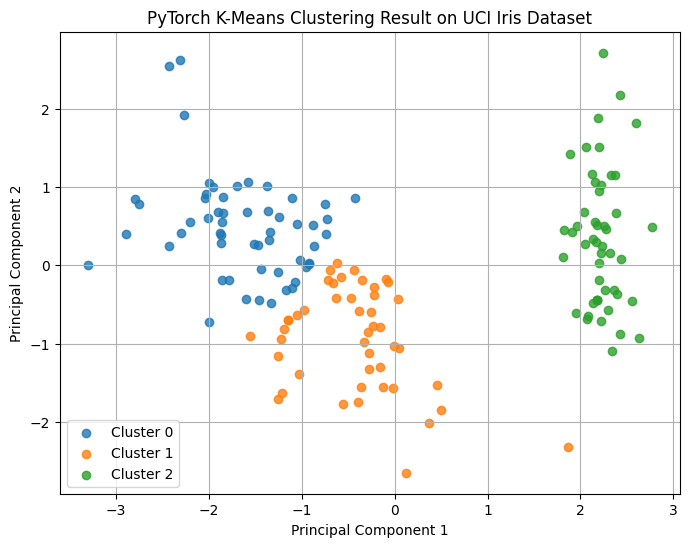

In [10]:
# 클러스터링 결과를 2차원 산점도로 시각화합니다.
plt.figure(figsize=(8, 6))

# 각 클러스터별로 점을 나누어 그립니다.
for cluster_id in range(k):
    # 현재 클러스터에 속한 샘플만 선택합니다.
    mask = cluster_labels == cluster_id

    # 첫 번째 주성분과 두 번째 주성분을 좌표로 사용하여 산점도를 그립니다.
    plt.scatter(
        X_pca_2d_np[mask, 0],
        X_pca_2d_np[mask, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.8
    )

# 그래프 제목을 설정합니다.
plt.title("PyTorch K-Means Clustering Result on UCI Iris Dataset")

# x축 이름을 설정합니다.
plt.xlabel("Principal Component 1")

# y축 이름을 설정합니다.
plt.ylabel("Principal Component 2")

# 범례를 표시합니다.
plt.legend()

# 격자를 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 10. 실제 품종과 클러스터 결과 비교

In [11]:
# 원본 데이터프레임을 복사하여 결과 확인용 데이터프레임을 만듭니다.
result_df = df.copy()

# 각 샘플의 클러스터 번호를 새 컬럼으로 추가합니다.
result_df["cluster"] = cluster_labels

# 실제 품종과 클러스터 번호의 관계를 교차표로 확인합니다.
cross_tab = pd.crosstab(result_df["species"], result_df["cluster"])

# 교차표를 출력합니다.
cross_tab

cluster,0,1,2
species,,,
Iris-setosa,0,1,49
Iris-versicolor,13,37,0
Iris-virginica,42,8,0


## 11. 여러 K값 비교

In [12]:
# 비교할 클러스터 개수 목록을 만듭니다.
k_values = list(range(2, 7))

# 각 K값의 Silhouette Score를 저장할 리스트를 만듭니다.
silhouette_scores = []

# K값을 2부터 6까지 바꾸면서 클러스터링을 반복합니다.
for current_k in k_values:
    # 현재 K값으로 PyTorch K-Means를 실행합니다.
    labels_tensor, _ = torch_kmeans(X_scaled, k=current_k, max_iters=100, tol=1e-4)

    # 평가 지표 계산을 위해 클러스터 라벨을 NumPy 배열로 변환합니다.
    labels_np = labels_tensor.cpu().numpy()

    # 현재 K값의 Silhouette Score를 계산합니다.
    score = silhouette_score(X_scaled.cpu().numpy(), labels_np)

    # 계산된 점수를 리스트에 저장합니다.
    silhouette_scores.append(score)

    # 현재 K값과 점수를 출력합니다.
    print(f"K={current_k}, Silhouette Score={score:.4f}")

반복 000 | 중심점 이동 거리: 1.184080
수렴 완료: 4회 반복
K=2, Silhouette Score=0.5802
반복 000 | 중심점 이동 거리: 1.341652
수렴 완료: 5회 반복
K=3, Silhouette Score=0.4590
반복 000 | 중심점 이동 거리: 1.587306
반복 010 | 중심점 이동 거리: 0.075809
반복 020 | 중심점 이동 거리: 0.057351
수렴 완료: 23회 반복
K=4, Silhouette Score=0.4140
반복 000 | 중심점 이동 거리: 1.693751
수렴 완료: 5회 반복
K=5, Silhouette Score=0.3473
반복 000 | 중심점 이동 거리: 1.716151
반복 010 | 중심점 이동 거리: 0.173180
수렴 완료: 17회 반복
K=6, Silhouette Score=0.3452


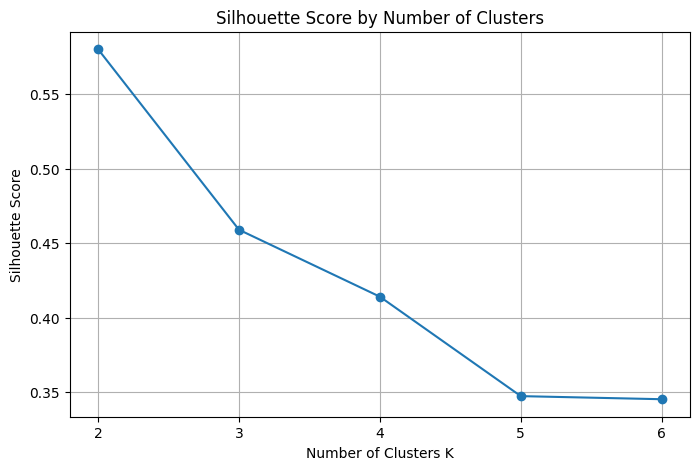

In [13]:
# K값별 Silhouette Score 변화를 선 그래프로 시각화합니다.
plt.figure(figsize=(8, 5))

# x축은 K값, y축은 Silhouette Score로 선 그래프를 그립니다.
plt.plot(k_values, silhouette_scores, marker="o")

# 그래프 제목을 설정합니다.
plt.title("Silhouette Score by Number of Clusters")

# x축 이름을 설정합니다.
plt.xlabel("Number of Clusters K")

# y축 이름을 설정합니다.
plt.ylabel("Silhouette Score")

# x축 눈금을 K값 목록으로 지정합니다.
plt.xticks(k_values)

# 격자를 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 12. 실습 정리

이 노트북은 UCI Iris 데이터셋을 인터넷에서 직접 다운로드한 뒤, PyTorch 텐서 연산으로 K-Means 클러스터링을 직접 구현합니다.  
라벨은 학습에 사용하지 않고, 결과 평가용으로만 사용합니다.  
따라서 비지도학습의 핵심인 “정답 없이 데이터 구조를 찾는 과정”을 확인할 수 있습니다.
